### Import Packages

In [1]:
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import altair as alt            # Visualize data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from icecream import ic         # Print variables.

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search


### Load Objects 

In [5]:
df_train = pd.read_parquet(f'../Experiment/Knee/data/interim/2.1-train.parquet')
df_test = pd.read_parquet(f'../Experiment/Knee/data/interim/2.1-test.parquet')

### Notebook Settings

In [6]:
# Pandas.
pd.set_option("display.max_rows", None)         # How many rows to display when printing a DataFrame? None shows all rows.
pd.set_option("display.max_columns", None)      # How many columns to display when printing a DataFrame? None shows all columns.
pd.set_option("display.max_info_columns", 100)  # How many rows to display for .info()?
pd.set_option("display.max_info_rows", 1000000) # How many columns to display for .info()?
pd.set_option("display.precision", 4)           # How many decimals to show when printing a DataFrame?

In [14]:
df_train.head(3)


,Provider Code,Procedure,Revision Flag,Year,Age Band,Gender,Pre-Op Q Assisted,Pre-Op Q Assisted By,Pre-Op Q Symptom Period,Pre-Op Q Previous Surgery,Pre-Op Q Living Arrangements,Pre-Op Q Disability,Heart Disease,High Bp,Stroke,Circulation,Lung Disease,Diabetes,Kidney Disease,Nervous System,Liver Disease,Cancer,Depression,Arthritis,Pre-Op Q Mobility,Pre-Op Q Self-Care,Pre-Op Q Activity,Pre-Op Q Discomfort,Pre-Op Q Anxiety,Pre-Op Q EQ5D Index Profile,Pre-Op Q EQ5D Index,Post-Op Q EQ5D Index Profile,Knee Replacement Pre-Op Q Pain,Knee Replacement Pre-Op Q Night Pain,Knee Replacement Pre-Op Q Washing,Knee Replacement Pre-Op Q Transport,Knee Replacement Pre-Op Q Walking,Knee Replacement Pre-Op Q Standing,Knee Replacement Pre-Op Q Limping,Knee Replacement Pre-Op Q Kneeling,Knee Replacement Pre-Op Q Work,Knee Replacement Pre-Op Q Confidence,Knee Replacement Pre-Op Q Shopping,Knee Replacement Pre-Op Q Stairs,Knee Replacement Pre-Op Q Score,health_gain
0,268,1,0,3,5,2.0,2,1,2,2,2,1,1,0,0,0,1,0,1,0,0,0,0,1,2,2,2,3,2,22232,-0.016,22222,0,0,3,1,1,1,0,0,0,1,0,0,7.0,16.0
1,69,1,0,2,4,1.0,2,1,2,2,1,2,0,0,0,0,0,0,0,0,0,0,0,1,2,1,2,2,2,21222,0.620,11222,1,4,3,3,0,2,1,2,2,3,3,2,26.0,12.0
2,267,1,0,2,2,2.0,2,1,4,2,1,2,0,1,0,0,0,0,0,0,0,0,0,1,2,2,2,2,1,22221,0.587,21221,1,2,3,2,2,2,1,1,1,2,1,2,20.0,8.0


In [16]:
df_train.shape


(94550, 46)

### Check Missing Values

In [19]:
n_obs = df_train.shape[0]

In [20]:
# Pandas.
df_train_missing = (
    
    pd.DataFrame({

        'data_type':    df_train.dtypes,
        'missing':      (df_train.isnull() | df_train.eq('*')).sum()   
    })

    # Add complete%
    .assign(
        complete_pct = lambda x: round(100 * (n_obs - x['missing']) / n_obs, 2)
    )

    # Remove variables that are complete.
    #.query("complete_pct < 100")

    # Sort table by number of missing data in ascending order.
    .sort_values(
        by        = 'complete_pct',
        ascending = True
    )
)

df_train_missing

,data_type,missing,complete_pct
Provider Code,int32,0,100.0
Procedure,int32,0,100.0
Revision Flag,uint8,0,100.0
Year,int32,0,100.0
Age Band,int32,0,100.0
Gender,float32,0,100.0
Pre-Op Q Assisted,uint8,0,100.0
Pre-Op Q Assisted By,int32,0,100.0
Pre-Op Q Symptom Period,uint8,0,100.0
Pre-Op Q Previous Surgery,uint8,0,100.0


array([[<Axes: title={'center': 'Provider Code'}>,
        <Axes: title={'center': 'Procedure'}>,
        <Axes: title={'center': 'Revision Flag'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Age Band'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Pre-Op Q Assisted'}>],
       [<Axes: title={'center': 'Pre-Op Q Assisted By'}>,
        <Axes: title={'center': 'Pre-Op Q Symptom Period'}>,
        <Axes: title={'center': 'Pre-Op Q Previous Surgery'}>,
        <Axes: title={'center': 'Pre-Op Q Living Arrangements'}>,
        <Axes: title={'center': 'Pre-Op Q Disability'}>,
        <Axes: title={'center': 'Heart Disease'}>,
        <Axes: title={'center': 'High Bp'}>],
       [<Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'Circulation'}>,
        <Axes: title={'center': 'Lung Disease'}>,
        <Axes: title={'center': 'Diabetes'}>,
        <Axes: title={'center': 'Kidney Disease'}>,
        <Axes: title

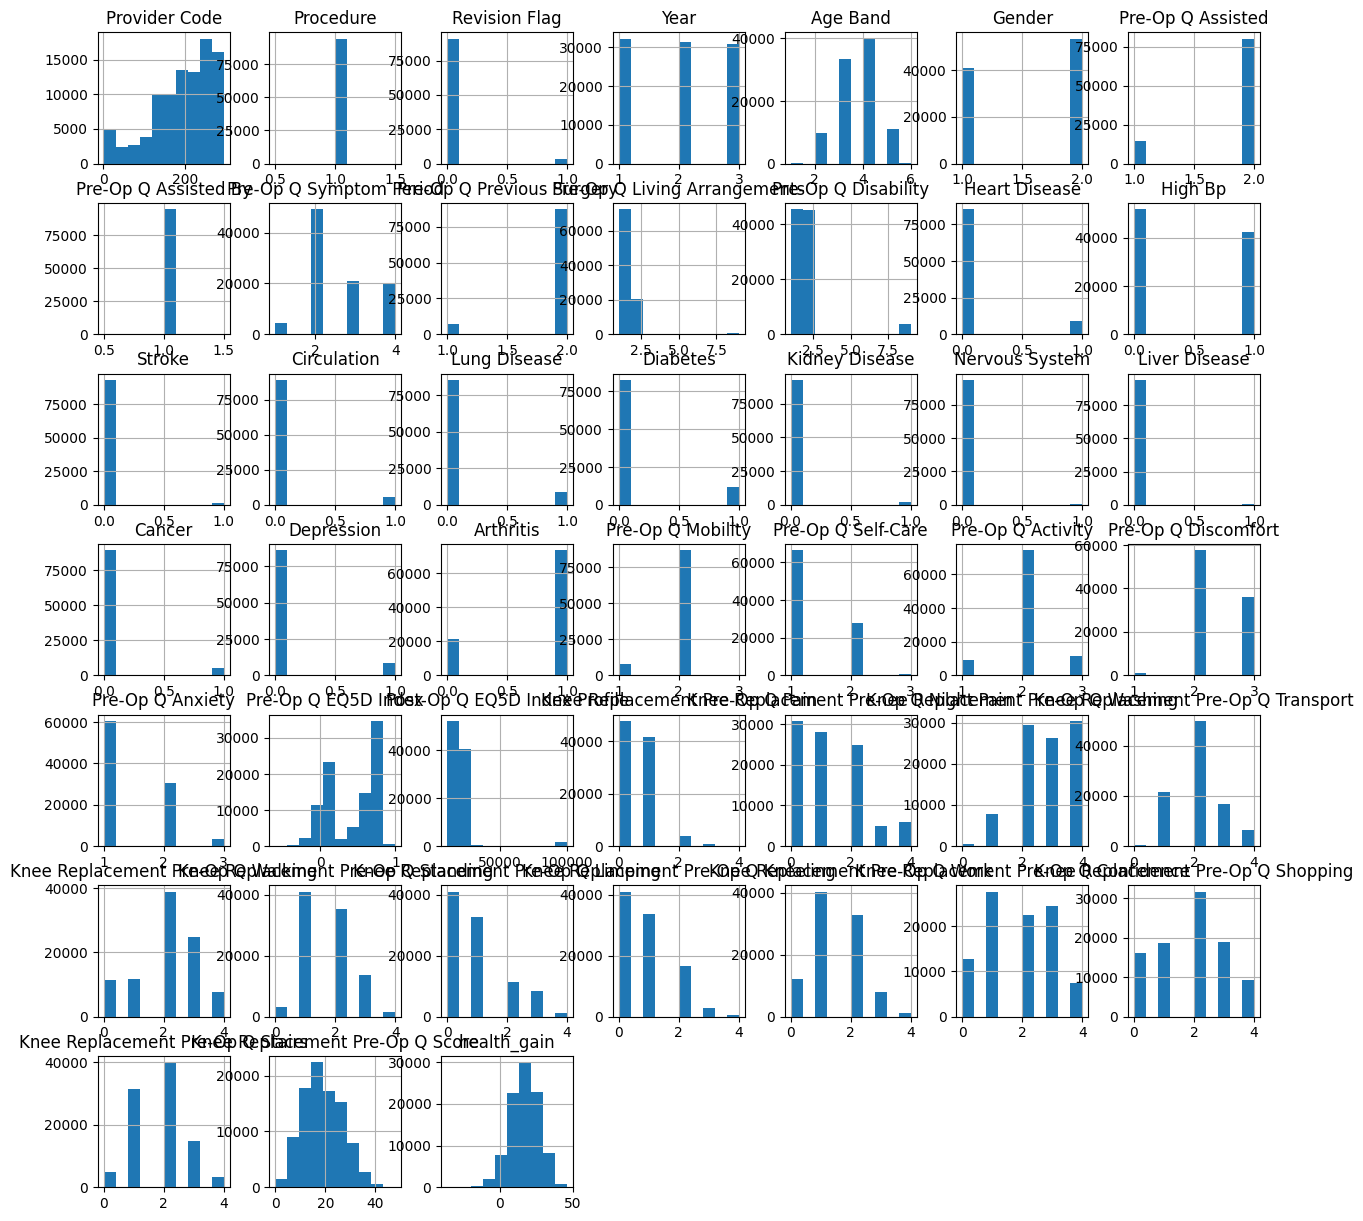

In [21]:
df_train.hist(figsize=(15,15))

### Seperate Features & Target

In [ ]:
y = df_train['health_gain_log']  # Use log-transformed target
X = df_train.drop(['health_gain', 'health_gain_log', 'Procedure', 'Pre-Op Q Assisted By'], axis=1)

### Estimate a Linear Regression, LASSO & KNN